# Problem Statement 3
## Customer Purchase Prediction using Machine Learning

## Load and Understand The Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("PS 3 Social_Network_Ads.csv")

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


## Data Preprocessing And Encoding

In [4]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df.shape

(400, 5)

In [6]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [8]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

## EDA (Exploratory Data Analysis)

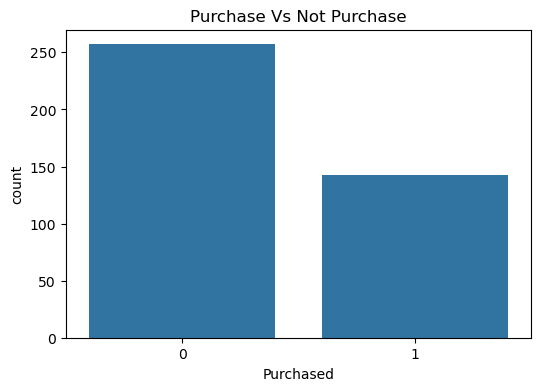

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Purchased",data=df)
plt.title("Purchase Vs Not Purchase")
plt.show()

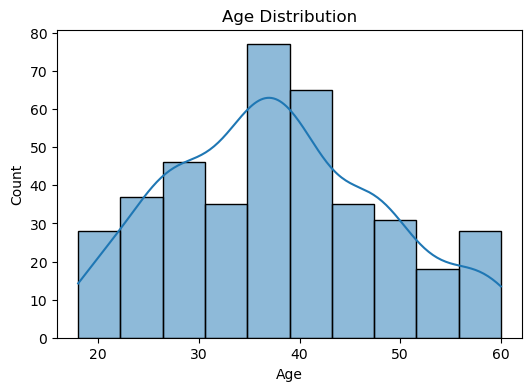

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution")
plt.show()

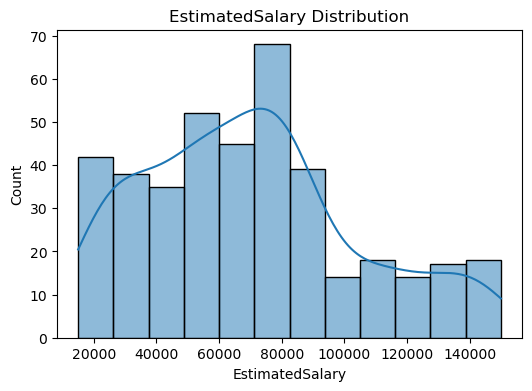

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['EstimatedSalary'],kde=True)
plt.title("EstimatedSalary Distribution")
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
le=LabelEncoder()

In [16]:
df["Gender"]=le.fit_transform(df["Gender"])

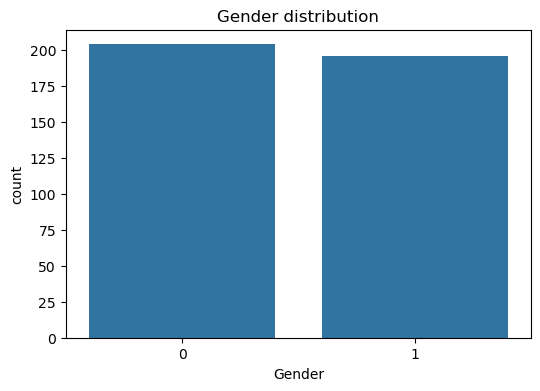

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender",data=df)
plt.title("Gender distribution")
plt.show()

In [18]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


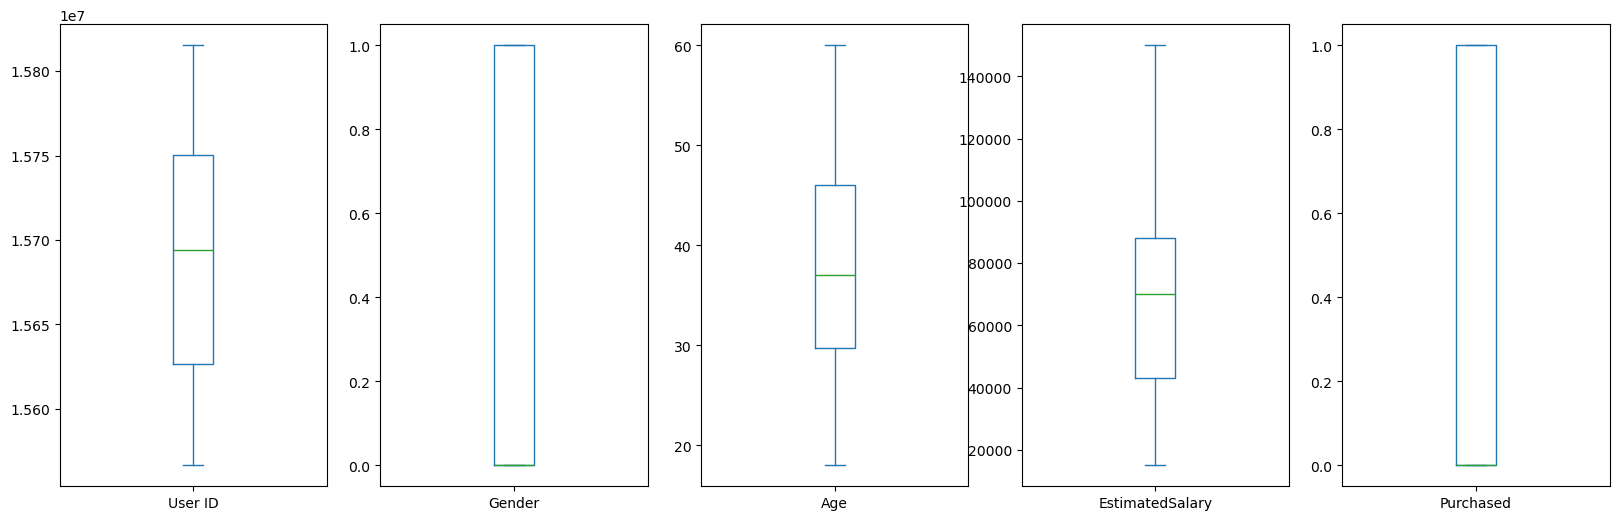

In [32]:
axes=df.plot(kind="box",sharey=False,subplots=True,figsize=(20,6))
plt.show()

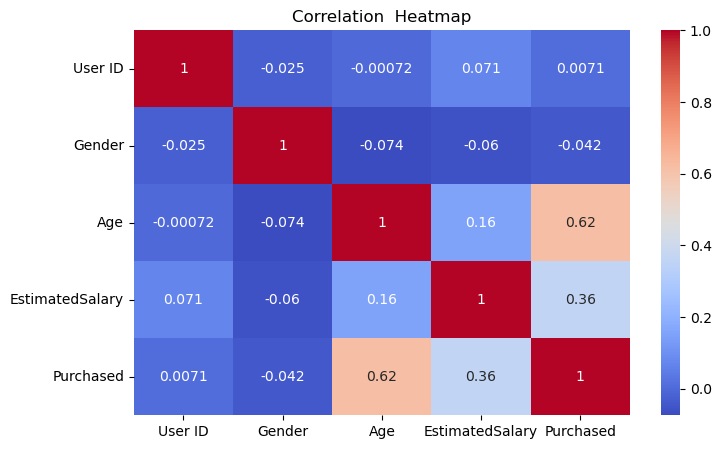

In [27]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation  Heatmap')
plt.show()

In [25]:
df.corr()

,User ID,Gender,Age,EstimatedSalary,Purchased
User ID,1.000000,-0.025249,-0.000721,0.071097,0.007120
Gender,-0.025249,1.000000,-0.073741,-0.060435,-0.042469
Age,-0.000721,-0.073741,1.000000,0.155238,0.622454
EstimatedSalary,0.071097,-0.060435,0.155238,1.000000,0.362083
Purchased,0.007120,-0.042469,0.622454,0.362083,1.000000


## Model Fitting And Evaluation

In [36]:
x=df.drop("Purchased",axis=1)
y=df["Purchased"]

In [39]:
from sklearn.linear_model import LogisticRegression

In [56]:
from sklearn.datasets import make_classification

In [40]:
from sklearn.model_selection import train_test_split

In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay

In [47]:
log=LogisticRegression()

In [48]:
x

,User ID,Gender,Age,EstimatedSalary
0,15624510,1,19,19000
1,15810944,1,35,20000
2,15668575,0,26,43000
3,15603246,0,27,57000
4,15804002,1,19,76000
...,...,...,...,...
395,15691863,0,46,41000
396,15706071,1,51,23000
397,15654296,0,50,20000
398,15755018,1,36,33000


In [51]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [83]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [84]:
log.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [85]:
y_pred=log.predict(x_test)

In [89]:
len(x_train)

280

In [90]:
len(y_train)

280

In [87]:
len(x_test)

120

In [88]:
len(y_test)

120

In [91]:
print(confusion_matrix(y_pred,y_test))

[[53  6]
 [ 7 54]]


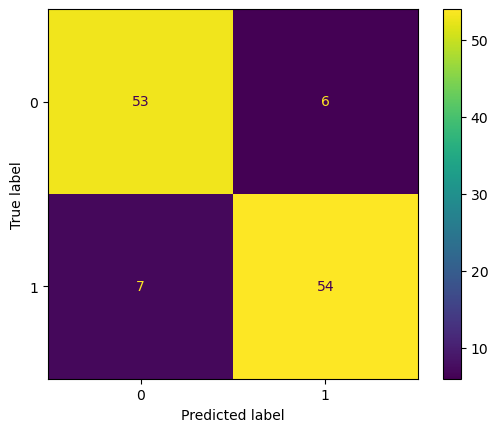

In [94]:
ConfusionMatrixDisplay.from_predictions(y_pred,y_test)
plt.show()

In [92]:
print(accuracy_score(y_pred,y_test))

0.8916666666666667


In [93]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89        59
           1       0.90      0.89      0.89        61

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120



## Hyper Parameter Tuning

In [95]:
penalty_values=["l1","l2","elasticnet"]
c_values=[100,10,1]
solver_values=['newton-cg','liblinear','sag','saga','lbfgs']

In [106]:
params=dict(penalty=penalty_values,C=c_values,solver=solver_values)
print(params)

{'penalty': ['l1', 'l2', 'elasticnet'], 'C': [100, 10, 1], 'solver': ['newton-cg', 'liblinear', 'sag', 'saga', 'lbfgs']}


## GridSearchCV

In [107]:
from sklearn.model_selection import GridSearchCV

In [108]:
from sklearn.model_selection import StratifiedKFold

In [109]:
fold=StratifiedKFold()

In [110]:
grid=GridSearchCV(estimator=log,param_grid=params,scoring="accuracy",cv=fold)

In [111]:
grid

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [112]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [113]:
grid.fit(x_train,y_train)

C:\Users\hi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\hi\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which 

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'liblinear', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [114]:
grid.best_params_

{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}

In [115]:
grid.best_score_

np.float64(0.9321428571428572)

In [116]:
y_pred=grid.predict(x_test)

In [118]:
print(confusion_matrix(y_pred,y_test))

[[54  5]
 [ 6 55]]


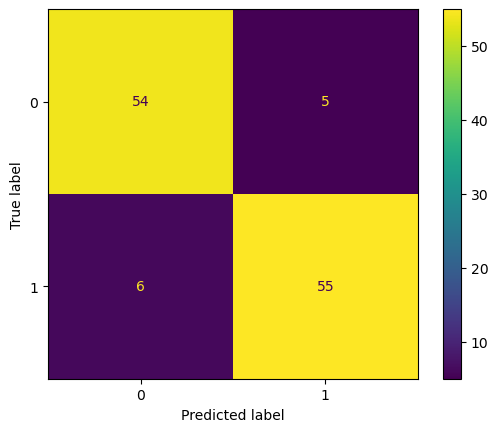

In [119]:
ConfusionMatrixDisplay.from_predictions(y_pred,y_test)

In [120]:
print(accuracy_score(y_pred,y_test))

0.9083333333333333


In [121]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91        59
           1       0.92      0.90      0.91        61

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120

